In [38]:
import os
import pickle
import numpy as np
import torch
import torch.nn.functional as F

def random_sample(features, subset=0.1):
    step = int(1/subset)
    offset = torch.randint(0,step,(1,)).item()
    return features[offset::step]

def create_visualizations(X, y, class_names=None, colors=None):
    """
    Create PCA and t-SNE plots for custom data
    
    Parameters:
    X: feature matrix (n_samples, n_features)
    y: labels (n_samples,)
    class_names: list of class names
    colors: list of colors for each class
    """
    if class_names is None:
        class_names = ['Class 0', 'Class 1']
    if colors is None:
        colors = ['red', 'blue']
    
    # Standardize the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    
    # Plot PCA
    for i, class_label in enumerate(np.unique(y)):
        mask = y == class_label
        ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=colors[i], label=class_names[i], alpha=0.7, s=50)
    
    ax1.set_title('PCA - Data Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot t-SNE
    for i, class_label in enumerate(np.unique(y)):
        mask = y == class_label
        ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                   c=colors[i], label=class_names[i], alpha=0.7, s=50)
    
    ax2.set_title('t-SNE - Data Distribution', fontsize=14, fontweight='bold')
    ax2.set_xlabel('t-SNE Component 1')
    ax2.set_ylabel('t-SNE Component 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return X_pca, X_tsne

## Visualize the initial CLIP distribution

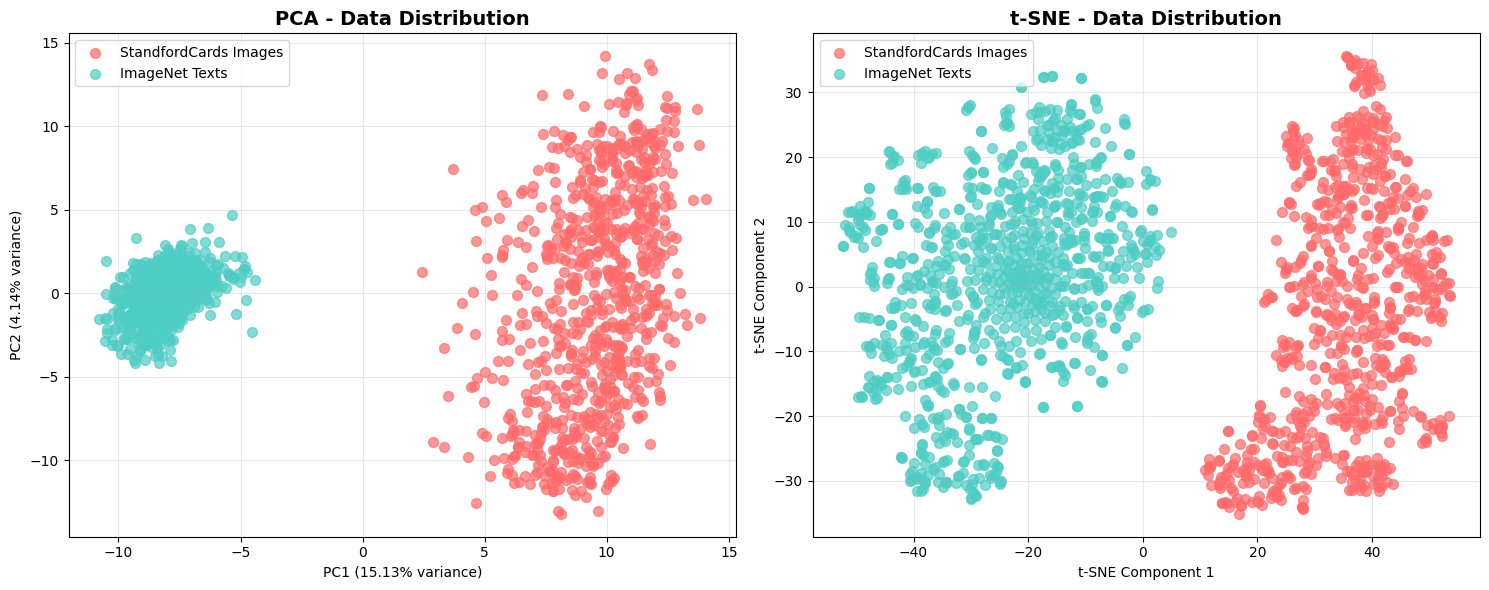

In [39]:
img_embs=F.normalize(random_sample(torch.load('/home/jonas/workspace/Cross-the-Gap/data/image_features/stanford_cars/ViT-B32/test/image_features.pt')))
txt_embs=F.normalize(torch.load('/home/jonas/workspace/Cross-the-Gap/data/imagenet_text_features.pt').cpu())
img_embs.shape, txt_embs.shape, img_embs.device, txt_embs.device

X_pca, X_tsne = create_visualizations(torch.cat([img_embs, txt_embs]), torch.tensor([0]*len(img_embs)+[1]*len(txt_embs)), 
                                    class_names=['StandfordCars Images', 'ImageNet Texts'], 
                                    colors=['#FF6B6B', '#4ECDC4'])

## Now project image embeds onto texts and back

In [58]:
pca = PCA(n_components=txt_embs.shape[1]//2).fit(txt_embs)
U = torch.tensor(pca.components_, device=img_embs.device, dtype=torch.float32)
img_embs_proj = F.normalize((U.T @ U @ img_embs.T).T)

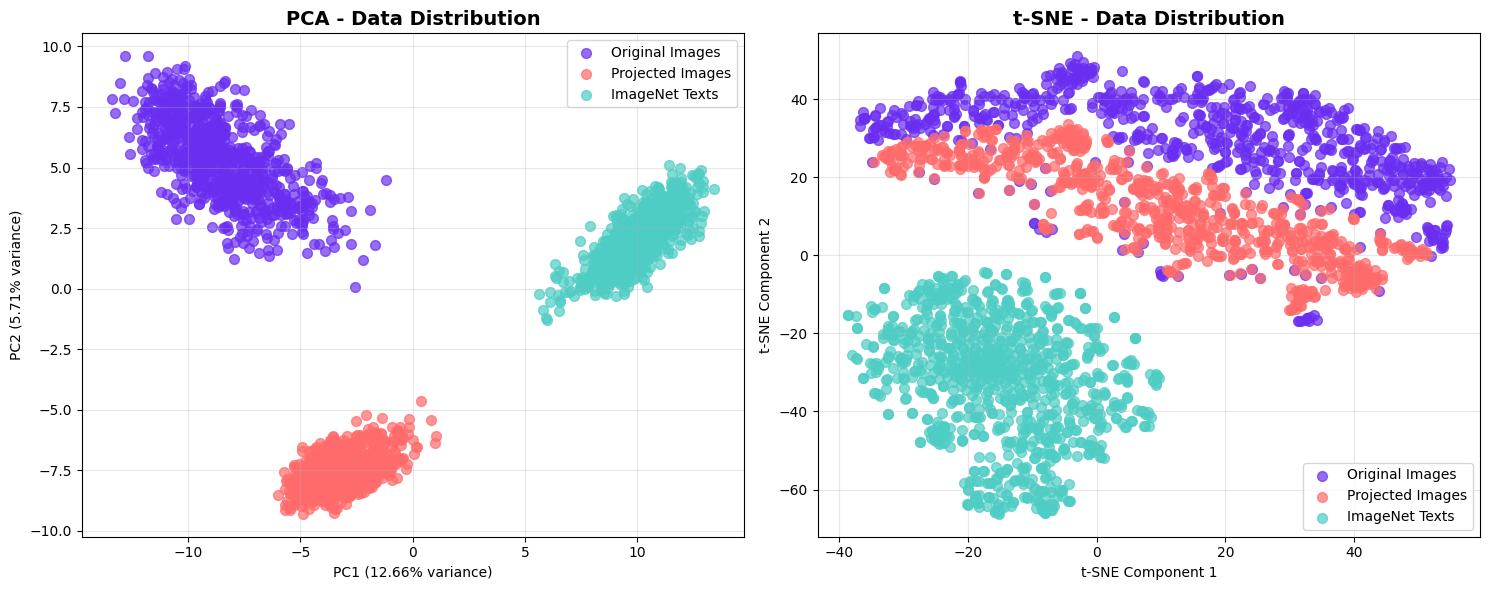

In [59]:
X_pca, X_tsne = create_visualizations(torch.cat([img_embs, img_embs_proj, txt_embs]), torch.tensor([0]*len(img_embs)+[1]*len(img_embs_proj)+[2]*len(txt_embs)), 
                                    class_names=['Original Images', 'Projected Images', 'ImageNet Texts'], 
                                    colors=['#6A2EF1', '#FF6B6B', '#4ECDC4'])

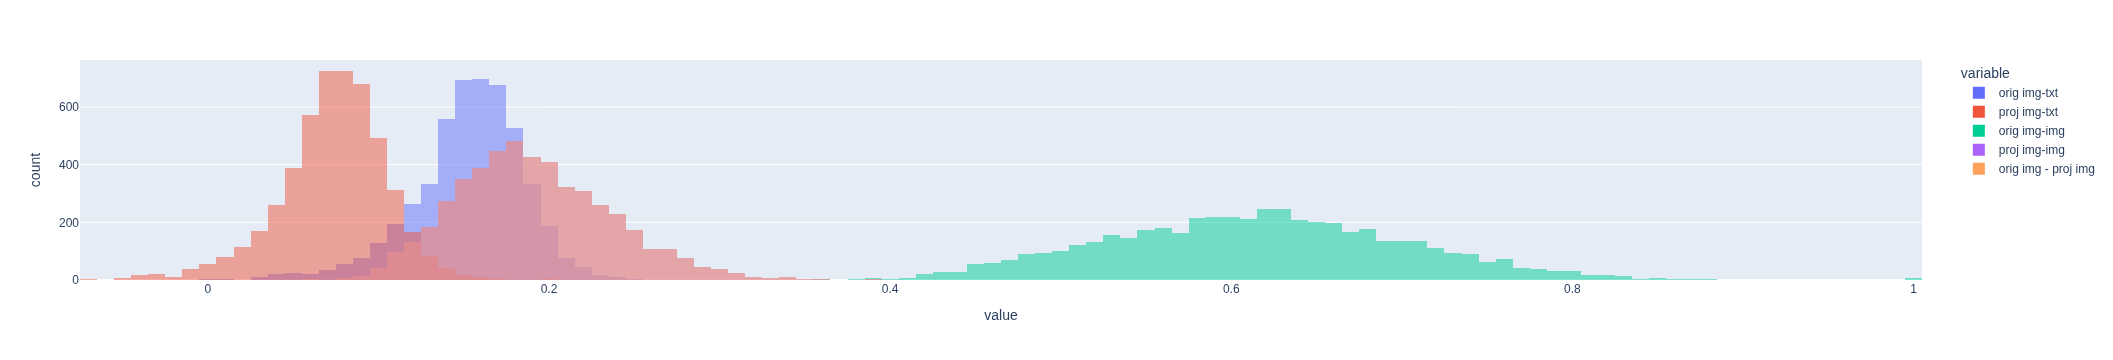

In [66]:
import plotly.express as px
display(px.histogram({
    'orig img-txt':(img_embs @ txt_embs.T).view(-1)[:5000], 
    'proj img-txt':(img_embs_proj @ txt_embs.T).view(-1)[:5000],
    'orig img-img':(img_embs @ img_embs.T).view(-1)[:5000],
    'proj img-img':(img_embs_proj @ img_embs_proj.T).view(-1)[:5000]
},barmode='overlay'))